# ORCA — Olist Delay Prediction Dataset EDA

**Purpose:** Exploratory Data Analysis (EDA) of the Brazilian Olist e-commerce dataset used as a proxy
for delivery delay prediction in the ORCA logistics intelligence platform.

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/olistbr/brazilian-ecommerce)  
**Target variable:** `is_delayed` — 1 if order was delivered after the estimated delivery date, 0 otherwise.  
**ML model:** LightGBM + CalibratedClassifierCV → delay probability per shipment.  

---
Run this notebook **after** `make build-features` has produced the parquet files.


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
PROCESSED = ROOT / 'data' / 'processed'

sys.path.insert(0, str(ROOT / 'apps' / 'orca-ai'))
from ml.features import FEATURE_COLUMNS

sns.set_theme(style='whitegrid', palette='muted')
print('FEATURE_COLUMNS:', FEATURE_COLUMNS)

In [ ]:
train = pd.read_parquet(PROCESSED / 'train_features.parquet')
test  = pd.read_parquet(PROCESSED / 'test_features.parquet')
full  = pd.concat([train, test], ignore_index=True)

print(f'Train rows : {len(train):,}   |  positive_rate = {train["is_delayed"].mean():.3f}')
print(f'Test rows  : {len(test):,}   |  positive_rate = {test["is_delayed"].mean():.3f}')
print(f'Total rows : {len(full):,}')
train.head()

Train rows : 77,176   |  positive_rate = 0.088
Test rows  : 19,294   |  positive_rate = 0.053
Total rows : 96,470


,order_id,order_purchase_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,seller_zip_code_prefix,hub_zone,is_delayed,distance_km,estimated_delivery_days,day_of_week_sin,day_of_week_cos,hour_of_day_sin,hour_of_day_cos,hub_zone_encoded,weather_severity_score,historical_hub_delay_rate,historical_driver_rate,item_count,product_weight_g
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38+00:00,2016-10-04 00:00:00+00:00,14600,81810.0,818,1,30.0,18.488449,0.433884,-0.900969,1.224647e-16,-1.000000,502,0.0,0.0,1.0,3,1000.0
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50+00:00,2016-10-27 00:00:00+00:00,4106,85801.0,858,0,30.0,23.593866,0.000000,1.000000,7.071068e-01,-0.707107,538,0.0,0.0,1.0,1,300.0
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50+00:00,2016-11-07 00:00:00+00:00,98280,15802.0,158,0,30.0,34.293866,0.000000,1.000000,-8.660254e-01,-0.500000,49,0.0,0.0,1.0,1,400.0
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36+00:00,2016-11-29 00:00:00+00:00,90040,18015.0,180,0,30.0,56.115556,0.000000,1.000000,-7.071068e-01,0.707107,65,0.0,0.0,1.0,1,767.0
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03+00:00,2016-11-23 00:00:00+00:00,13185,14940.0,149,0,30.0,50.079132,0.000000,1.000000,-5.000000e-01,0.866025,40,0.0,0.0,1.0,1,2050.0


## 1. Target Distribution — `is_delayed`

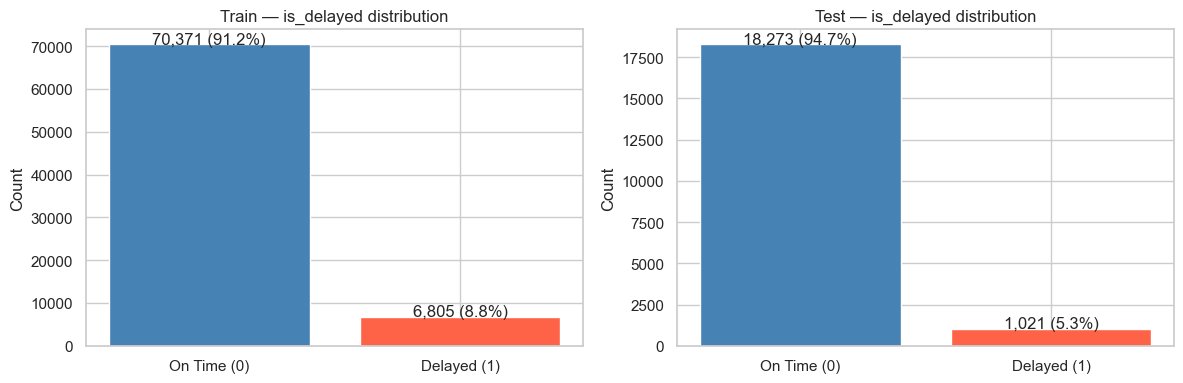


Class imbalance ratio (negative/positive): 10.34


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('Train', train), ('Test', test)]):
    counts = df['is_delayed'].value_counts()
    ax.bar(['On Time (0)', 'Delayed (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'{name} — is_delayed distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')

fig.tight_layout()
plt.show()
print('\nClass imbalance ratio (negative/positive):',
      round((train['is_delayed'] == 0).sum() / (train['is_delayed'] == 1).sum(), 2))

## 2. Feature Distributions

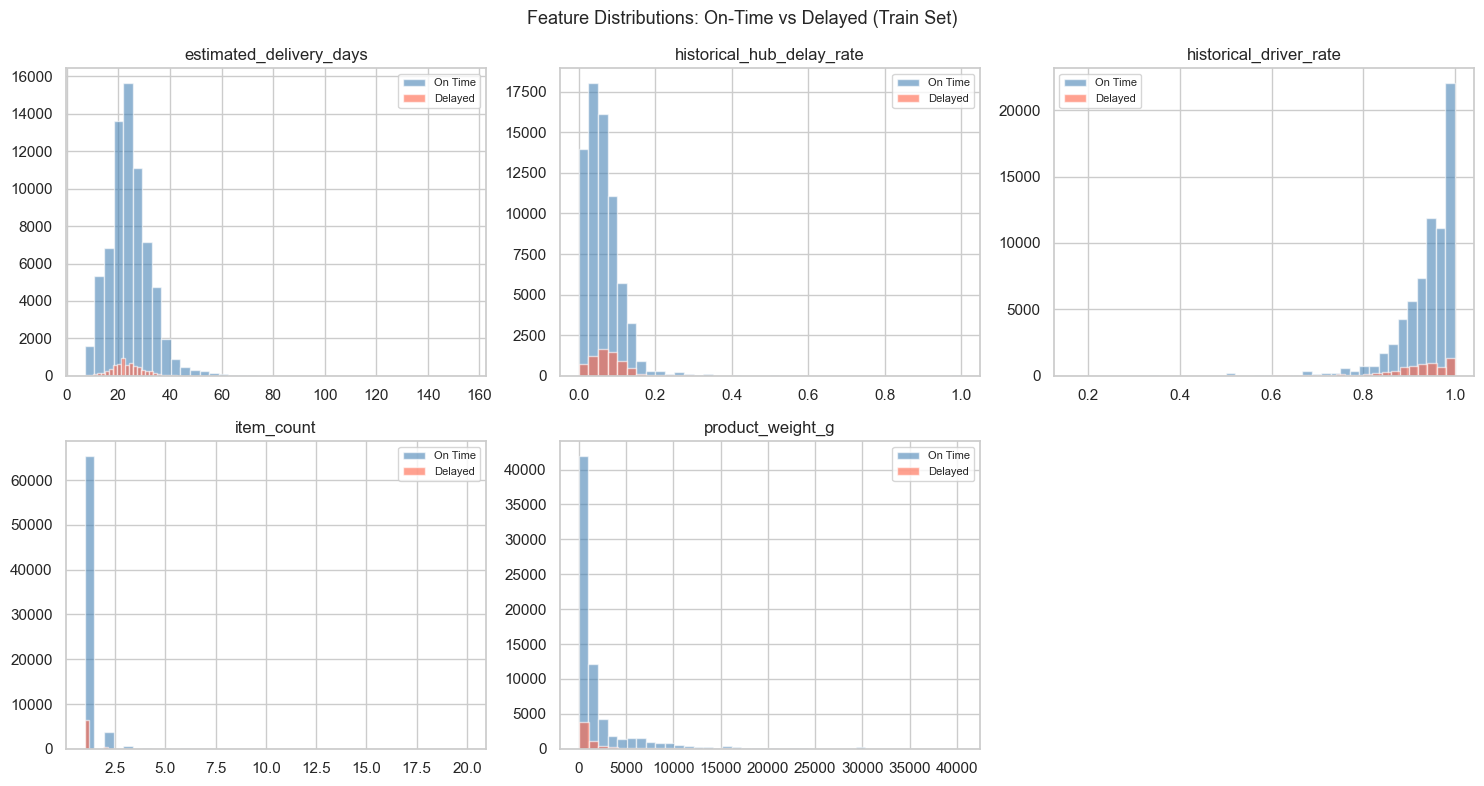

In [ ]:
numeric_features = [
    'estimated_delivery_days', 'historical_hub_delay_rate',
    'historical_driver_rate', 'item_count', 'product_weight_g'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    train[train['is_delayed'] == 0][feat].hist(ax=ax, bins=40, alpha=0.6, label='On Time', color='steelblue')
    train[train['is_delayed'] == 1][feat].hist(ax=ax, bins=40, alpha=0.6, label='Delayed', color='tomato')
    ax.set_title(feat)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions: On-Time vs Delayed (Train Set)', fontsize=13)
fig.tight_layout()
plt.show()

## 3. Temporal Drift — Train vs Test

Train period: 2016-09-15 → 2018-05-26
Test period : 2018-05-26 → 2018-08-29


C:\Users\hp\AppData\Local\Temp\ipykernel_26368\4217166273.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  train_copy['month'] = train_ts.dt.to_period('M')


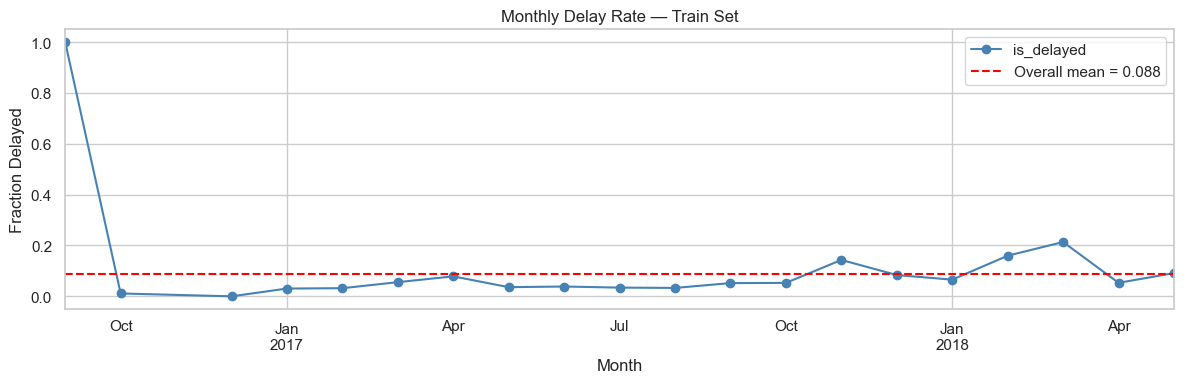

## 4. Hub Zone Analysis — Top Zones by Delay Rate

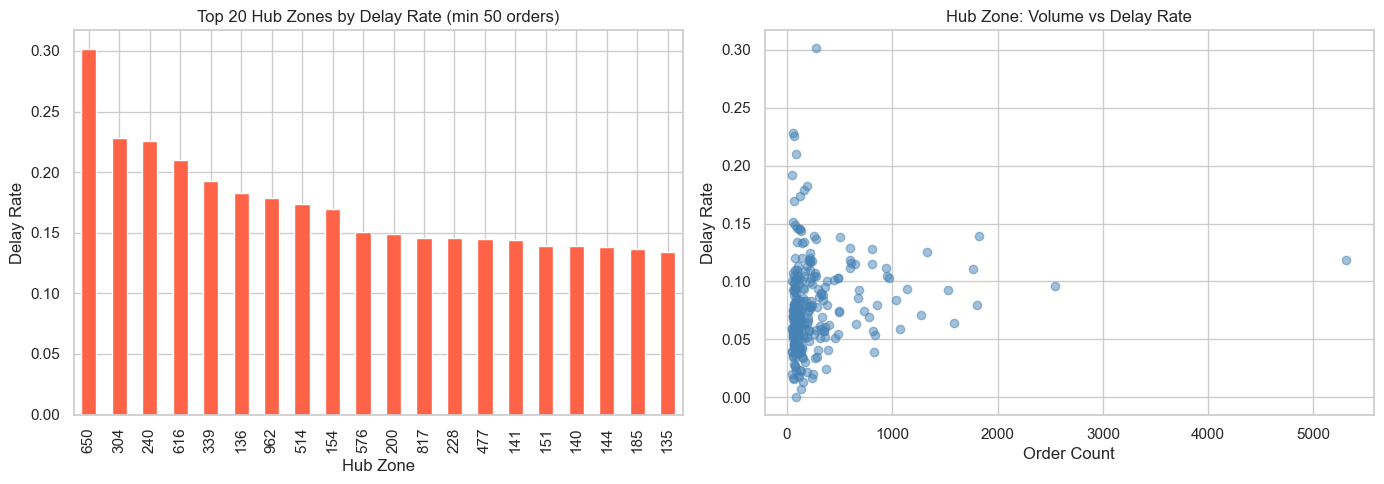


Total hub zones: 255
Highest delay zone: 650 (30.18%)


In [ ]:
hub_stats = (
    train.groupby('hub_zone')
    .agg(delay_rate=('is_delayed', 'mean'), order_count=('is_delayed', 'count'))
    .query('order_count >= 50')  # filter low-volume zones
    .sort_values('delay_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hub_stats.head(20)['delay_rate'].plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Top 20 Hub Zones by Delay Rate (min 50 orders)')
axes[0].set_ylabel('Delay Rate')
axes[0].set_xlabel('Hub Zone')

axes[1].scatter(hub_stats['order_count'], hub_stats['delay_rate'], alpha=0.5, color='steelblue')
axes[1].set_title('Hub Zone: Volume vs Delay Rate')
axes[1].set_xlabel('Order Count')
axes[1].set_ylabel('Delay Rate')

fig.tight_layout()
plt.show()
print(f'\nTotal hub zones: {len(hub_stats)}')
print(f'Highest delay zone: {hub_stats.index[0]} ({hub_stats["delay_rate"].iloc[0]:.2%})')

## 5. Feature Correlation with Target

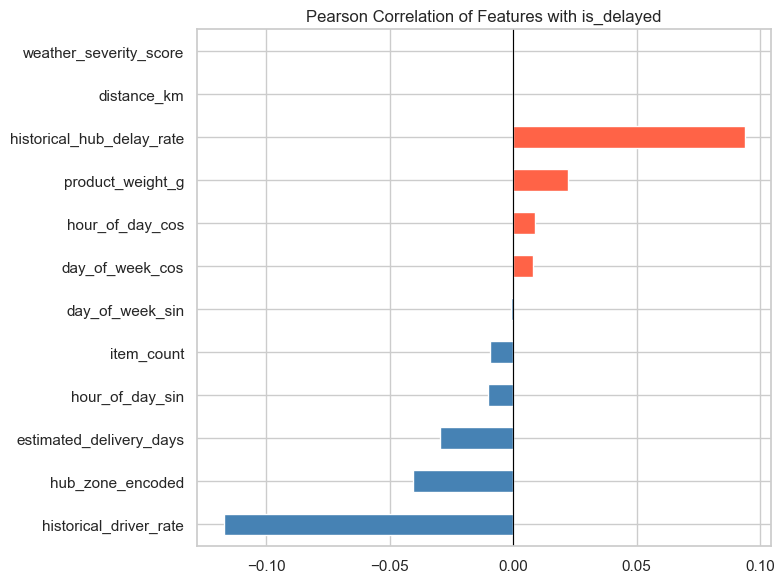

In [ ]:
corr = train[FEATURE_COLUMNS + ['is_delayed']].corr()['is_delayed'].drop('is_delayed').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Pearson Correlation of Features with is_delayed')
ax.axvline(0, color='black', linewidth=0.8)
fig.tight_layout()
plt.show()

## 6. Missing Values & Data Quality Check

In [ ]:
print('=== Missing Values (Train) ===')
missing = train[FEATURE_COLUMNS].isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values in feature columns.')

print('\n=== Feature Summary Statistics (Train) ===')
train[FEATURE_COLUMNS].describe().round(4)

=== Missing Values (Train) ===
product_weight_g    16
dtype: int64

=== Feature Summary Statistics (Train) ===


,distance_km,estimated_delivery_days,day_of_week_sin,day_of_week_cos,hour_of_day_sin,hour_of_day_cos,hub_zone_encoded,weather_severity_score,historical_hub_delay_rate,historical_driver_rate,item_count,product_weight_g
count,77176.0,77176.0000,77176.0000,77176.0000,77176.0000,77176.0000,77176.0000,77176.0,77176.0000,77176.0000,77176.0000,77160.0000
mean,30.0,24.3303,0.0773,0.0129,-0.3315,-0.2183,233.2363,0.0,0.0630,0.9371,1.1015,2162.8147
std,0.0,8.0575,0.6877,0.7218,0.5909,0.7024,205.5227,0.0,0.0533,0.0743,0.4634,3845.5457
min,30.0,7.0028,-0.9749,-0.9010,-1.0000,-1.0000,0.0000,0.0,0.0000,0.1667,1.0000,2.0000
25%,30.0,19.3535,-0.4339,-0.9010,-0.8660,-0.8660,40.0000,0.0,0.0330,0.9130,1.0000,300.0000
50%,30.0,23.4973,0.0000,-0.2225,-0.5000,-0.5000,188.0000,0.0,0.0558,0.9532,1.0000,700.0000
75%,30.0,28.4406,0.7818,0.6235,0.0000,0.5000,431.0000,0.0,0.0858,1.0000,1.0000,1850.0000
max,30.0,155.1355,0.9749,1.0000,1.0000,1.0000,652.0000,0.0,1.0000,1.0000,20.0000,40425.0000


## 7. Known Limitations of This Dataset

| Issue | Description | Mitigation |
|---|---|---|
| **Domain mismatch** | Olist is Brazilian e-commerce, not Indonesian logistics | Use as proxy; document limitations; note in model card |
| **`distance_km` = 30.0 for all** | Geolocation dataset not used; placeholder value | `olist_geolocation_dataset.csv` available for Haversine distance |
| **`weather_severity_score` = 0.0** | BMKG stub not integrated | Integrate BMKG API; add weather feature in v2 |
| **Historical rates initially 0** | First orders in each hub/seller have no history | Bayesian prior smoothing or global mean fallback |
| **Temporal coverage** | Olist spans 2016-2018 only | Limited seasonality patterns |
| **No GPS/IoT data** | Real logistics has live telemetry | Architect for streaming feature updates via Redis |

## 8. Recommended Next Steps for Feature v2

1. **Compute actual `distance_km`** using `olist_geolocation_dataset.csv` — Haversine distance between customer and seller zip centroids.
2. **Add `freight_value`** from `olist_order_items_dataset.csv` as a proxy for delivery priority.
3. **Add `review_score_mean`** from `olist_order_reviews_dataset.csv` as a seller quality signal.
4. **Integrate BMKG weather API** — weather severity at hub zone × dispatch timestamp.
5. **Bayesian prior smoothing** for `historical_hub_delay_rate` — blend expanding mean with global prior to handle cold-start zones.
